In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tunguz/70000-real-faces-1")

print("Path to dataset files:", path)

100%|██████████| 19.1G/19.1G [02:59<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tunguz/70000-real-faces-1/versions/10


In [5]:
!pip install mediapipe opencv-python-headless


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 11.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found ex

In [1]:
import cv2
import mediapipe as mp
import numpy as np
import os
import json
from google.colab.patches import cv2_imshow
from tqdm import tqdm


In [2]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/tunguz/70000-real-faces-1/versions/10"

# Collect all image files recursively from all subfolders
all_images = []
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, f))

print(f"Total image files found: {len(all_images)}")

# Use first 2000 for processing
image_paths = all_images[:2000]
print(f"Using {len(image_paths)} images for landmark extraction.")


Total image files found: 15000
Using 2000 images for landmark extraction.


Sample image shape: (1024, 1024, 3)


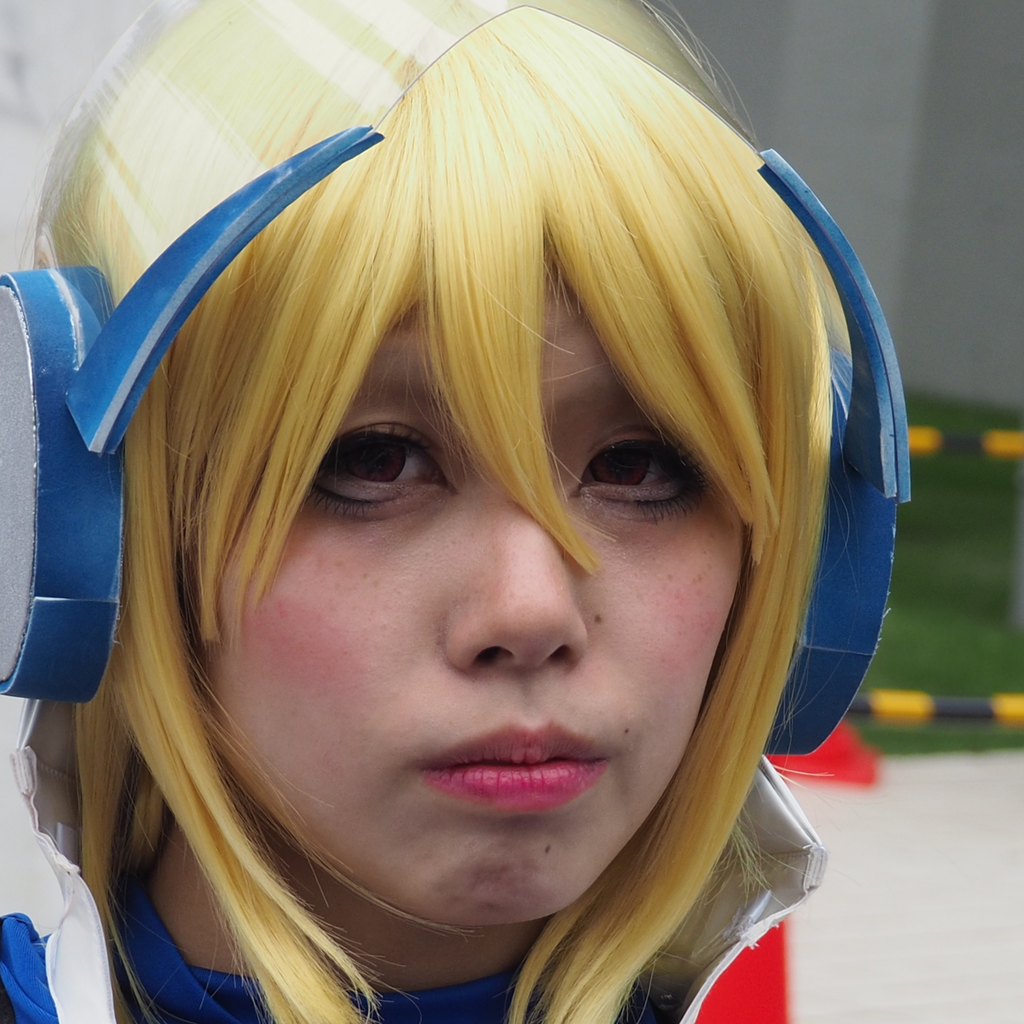

In [3]:
import cv2
from google.colab.patches import cv2_imshow

# Show one random sample
if len(image_paths) > 0:
    img = cv2.imread(image_paths[0])
    print("Sample image shape:", img.shape)
    cv2_imshow(img)
else:
    print("⚠️ No images found. Check your dataset path again.")


In [4]:
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)

# Landmark indices for glasses fitting (around eyes, nose, ears)
landmark_indices = [133, 33, 159, 263, 362, 386, 6, 197, 127, 356]


In [5]:
output_folder = "/content/processed_faces"
os.makedirs(output_folder, exist_ok=True)

landmarks_data = {}

for img_path in tqdm(image_paths, desc="Processing images"):
    image = cv2.imread(img_path)
    if image is None:
        continue

    # Resize for consistency (improves speed and stability)
    image = cv2.resize(image, (640, 640))
    h, w, _ = image.shape

    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb_image)

    if not results.multi_face_landmarks:
        continue

    for face_landmarks in results.multi_face_landmarks:
        points = []
        for idx in landmark_indices:
            lm = face_landmarks.landmark[idx]
            x, y = int(lm.x * w), int(lm.y * h)
            points.append({"x": x, "y": y})
            # Draw the points on image
            cv2.circle(image, (x, y), 3, (0, 255, 0), -1)
            cv2.putText(image, str(idx), (x+5, y-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)

        # Save landmarks in dictionary
        landmarks_data[os.path.basename(img_path)] = points

        # Save processed image
        save_path = os.path.join(output_folder, os.path.basename(img_path))
        cv2.imwrite(save_path, image)


Processing images: 100%|██████████| 2000/2000 [02:38<00:00, 12.65it/s]


In [6]:
output_json = "/content/facial_landmarks_2000.json"

with open(output_json, "w") as f:
    json.dump(landmarks_data, f, indent=4)

print(f"✅ Saved landmarks for {len(landmarks_data)} images to {output_json}")


✅ Saved landmarks for 2000 images to /content/facial_landmarks_2000.json


Showing: 08719.png


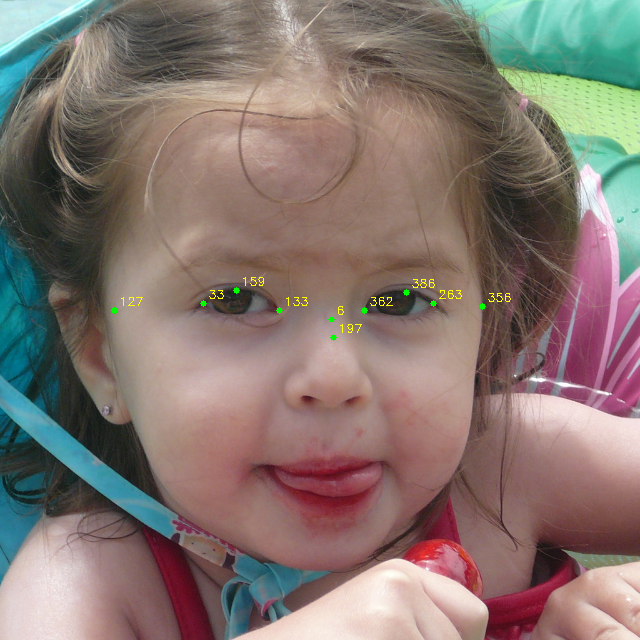

In [9]:
if len(landmarks_data) > 0:
    sample_image = list(landmarks_data.keys())[6]
    img_path = os.path.join(output_folder, sample_image)
    print(f"Showing: {sample_image}")
    cv2_imshow(cv2.imread(img_path))
else:
    print("⚠️ No faces detected — check sample images or adjust confidence.")


In [ ]:
!pip install timm==0.9.2 albumentations==1.3.1 opencv-python-headless==4.7.0.72 tqdm


In [10]:
import os
import math
import json
import random
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Repro
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [11]:
# Paths
IMAGES_DIR = "/content/processed_faces"
LANDMARK_JSON = "/content/facial_landmarks_2000.json"

# Parameters
NUM_POINTS = 10
OUT_DIM = NUM_POINTS * 2
IMAGE_SIZE = 299  # Inception v3 default
BATCH_SIZE = 16
NUM_EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-5

# Split ratios
VAL_SPLIT = 0.15
TEST_SPLIT = 0.10  # 10% test

print("✅ Image dir:", os.path.exists(IMAGES_DIR))
print("✅ JSON file:", os.path.exists(LANDMARK_JSON))


✅ Image dir: True
✅ JSON file: True


In [12]:
with open(LANDMARK_JSON, "r") as f:
    landmarks_data = json.load(f)

print(f"Total labeled images: {len(landmarks_data)}")

# Show sample
first_key = list(landmarks_data.keys())[0]
print("Sample filename:", first_key)
print("Landmarks:", landmarks_data[first_key])


Total labeled images: 2000
Sample filename: 08949.png
Landmarks: [{'x': 281, 'y': 298}, {'x': 202, 'y': 292}, {'x': 236, 'y': 274}, {'x': 425, 'y': 296}, {'x': 362, 'y': 299}, {'x': 401, 'y': 281}, {'x': 337, 'y': 314}, {'x': 340, 'y': 332}, {'x': 107, 'y': 304}, {'x': 455, 'y': 311}]


In [13]:
class FaceLandmarkDataset(Dataset):
    def __init__(self, images_dir, landmarks_dict, filenames=None, transform=None, image_size=299):
        self.images_dir = images_dir
        self.landmarks_dict = landmarks_dict
        self.transform = transform
        self.image_size = image_size

        all_files = filenames if filenames is not None else list(landmarks_dict.keys())
        self.samples = []
        for f in all_files:
            path = os.path.join(images_dir, f)
            if os.path.exists(path) and len(landmarks_dict.get(f, [])) == 10:
                self.samples.append(f)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname = self.samples[idx]
        img_path = os.path.join(self.images_dir, fname)
        img = Image.open(img_path).convert("RGB")

        orig_w, orig_h = img.size
        kps = np.array([[p["x"], p["y"]] for p in self.landmarks_dict[fname]], dtype=np.float32)

        if self.transform:
            img = self.transform(img)

        # scale to resized image dimensions
        scale_x, scale_y = IMAGE_SIZE / orig_w, IMAGE_SIZE / orig_h
        kps[:, 0] *= scale_x
        kps[:, 1] *= scale_y

        kps = kps.flatten()
        return img, torch.tensor(kps, dtype=torch.float32), fname


In [14]:
import os, json, random
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models


In [15]:
# Transforms (no flip for now, to keep landmark consistency)
SEED=42
base_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = FaceLandmarkDataset(IMAGES_DIR, landmarks_data, transform=base_transform)
total = len(dataset)

# Calculate split lengths
test_len = int(total * TEST_SPLIT)
val_len = int(total * VAL_SPLIT)
train_len = total - val_len - test_len

train_ds, val_ds, test_ds = random_split(
    dataset, [train_len, val_len, test_len], generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"✅ Dataset sizes → Train: {train_len}, Val: {val_len}, Test: {test_len}")


✅ Dataset sizes → Train: 1500, Val: 300, Test: 200


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [16]:
import torchvision.models as models
from torchvision.models import Inception_V3_Weights

def create_inception_landmark_model(out_dim):
    # Use the official weights class from torchvision >=0.15
    weights = Inception_V3_Weights.IMAGENET1K_V1
    model = models.inception_v3(weights=weights)  # <-- don't pass aux_logits=False here
    # Disable auxiliary outputs manually (not needed for our regression task)
    model.aux_logits = False
    # Replace final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, out_dim)
    return model

model = create_inception_landmark_model(OUT_DIM).to(device)
print("✅ Model ready (Inception v3, fixed for new torchvision)")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 192MB/s] 


✅ Model ready (Inception v3, fixed for new torchvision)


In [17]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)


In [18]:
best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for imgs, targets, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]"):
        imgs, targets = imgs.to(device), targets.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, targets, _ in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            preds = model(imgs)
            loss = criterion(preds, targets)
            val_loss += loss.item() * imgs.size(0)

    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)

    print(f"📘 Epoch {epoch} → Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/best_inception_landmark.pth")
        print("✅ Best model saved!")


Epoch 1/50 [train]: 100%|██████████| 94/94 [00:32<00:00,  2.87it/s]


📘 Epoch 1 → Train Loss: 21795.5269 | Val Loss: 20239.3798
✅ Best model saved!


Epoch 2/50 [train]: 100%|██████████| 94/94 [00:26<00:00,  3.52it/s]


📘 Epoch 2 → Train Loss: 19150.0456 | Val Loss: 17541.5877
✅ Best model saved!


Epoch 3/50 [train]: 100%|██████████| 94/94 [00:27<00:00,  3.39it/s]


...

📘 Epoch 48 → Train Loss: 38.1836 | Val Loss: 30.3962


Epoch 49/50 [train]: 100%|██████████| 94/94 [00:26<00:00,  3.54it/s]


📘 Epoch 49 → Train Loss: 36.5070 | Val Loss: 24.0284


Epoch 50/50 [train]: 100%|██████████| 94/94 [00:26<00:00,  3.54it/s]


📘 Epoch 50 → Train Loss: 36.2624 | Val Loss: 19.0919
✅ Best model saved!


In [19]:

model.load_state_dict(torch.load("/content/best_inception_landmark.pth", map_location=device))
model.eval()

test_loss = 0.0
with torch.no_grad():
    for imgs, targets, _ in tqdm(test_loader, desc="Testing"):
        imgs, targets = imgs.to(device), targets.to(device)
        preds = model(imgs)
        loss = criterion(preds, targets)
        test_loss += loss.item() * imgs.size(0)

test_loss /= len(test_loader.dataset)
print(f"🎯 Final Test Loss: {test_loss:.4f}")


Testing: 100%|██████████| 13/13 [00:03<00:00,  3.65it/s]

🎯 Final Test Loss: 20.8200


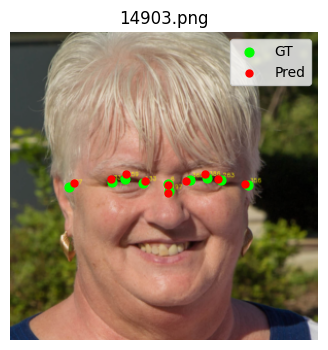

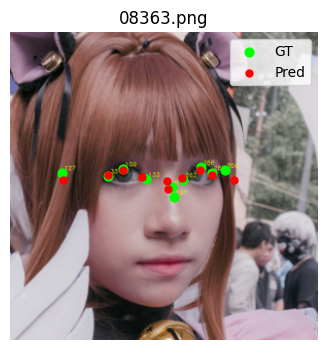

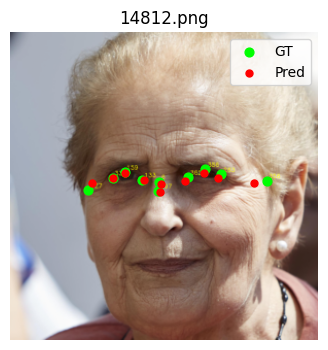

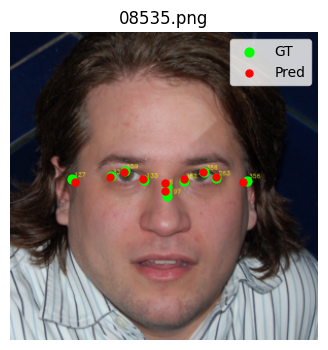

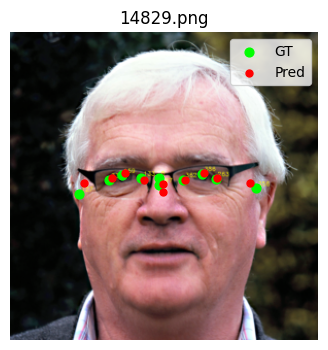

In [20]:
inv_normalize = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

def visualize_predictions(model, loader, num=5):
    model.eval()
    shown = 0
    with torch.no_grad():
        for imgs, targets, fnames in loader:
            imgs = imgs.to(device)
            preds = model(imgs).cpu().numpy()
            targets = targets.numpy()

            for i in range(len(imgs)):
                img = inv_normalize(imgs[i].cpu()).permute(1,2,0).numpy()
                img = np.clip(img, 0, 1)
                plt.figure(figsize=(4,4))
                plt.imshow(img)

                p = preds[i].reshape(-1, 2)
                t = targets[i].reshape(-1, 2)
                plt.scatter(t[:,0], t[:,1], c='lime', s=40, label='GT')
                plt.scatter(p[:,0], p[:,1], c='red', s=25, label='Pred')
                plt.title(fnames[i])
                plt.legend()
                plt.axis('off')
                plt.show()

                shown += 1
                if shown >= num:
                    return

# Show predictions on test set
visualize_predictions(model, test_loader, num=5)


In [21]:

from PIL import Image
import cv2
import numpy as np
import torch

def predict_landmarks(model, image_path, transform, device='cuda'):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((299, 299))  # Inception input size
    input_tensor = transform(image=np.array(img_resized))["image"]
    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        preds = model(input_tensor).cpu().numpy().reshape(-1, 2)

    # Denormalize points to original image size
    w, h = img.size
    preds[:, 0] *= w
    preds[:, 1] *= h

    # Visualize
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    for (x, y) in preds.astype(int):
        cv2.circle(img_cv, (x, y), 4, (0, 255, 0), -1)
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return preds


In [22]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Same preprocessing used during training
transform = A.Compose([
    A.Resize(299, 299),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


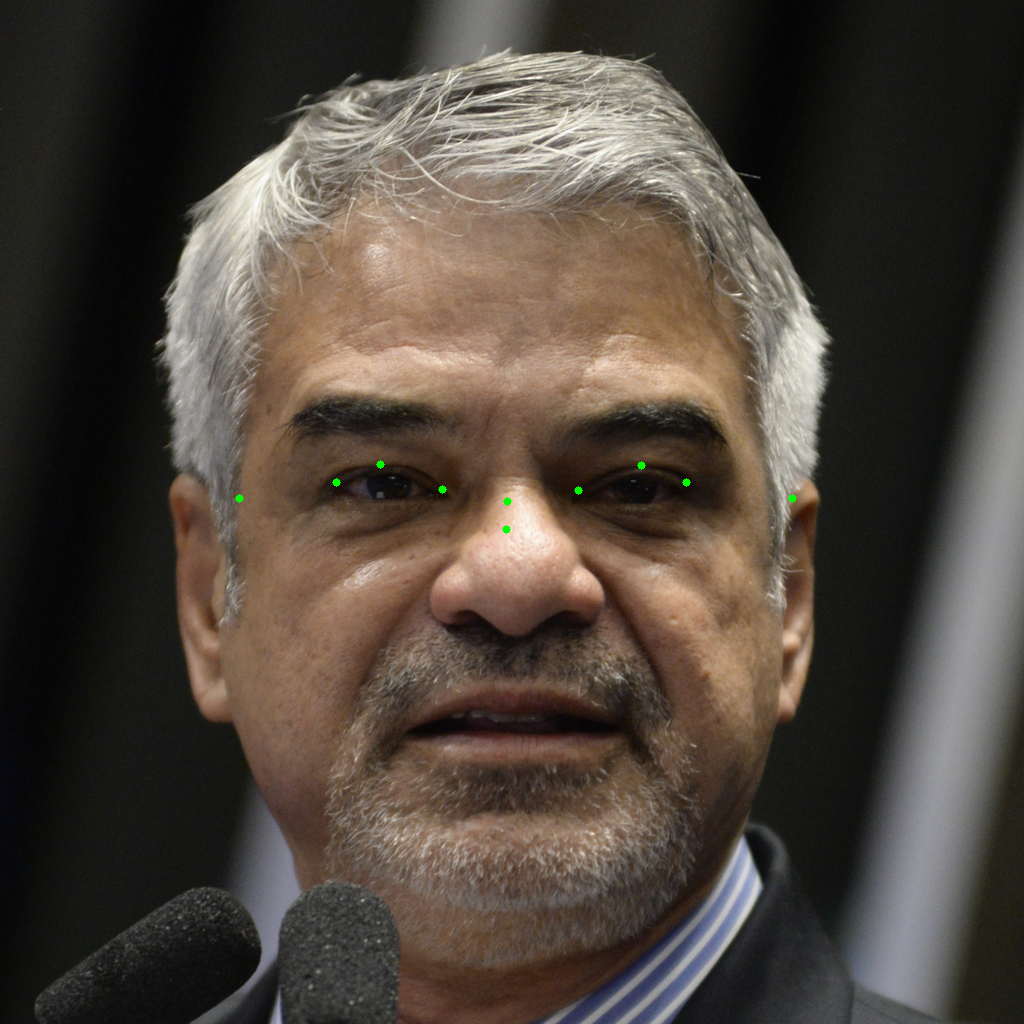

✅ Saved result with landmarks → /content/predicted_landmarks.png


In [24]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch

# ✅ Preprocessing (same as during training)
transform = A.Compose([
    A.Resize(299, 299),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ✅ Function to predict and visualize points
def predict_and_show_landmarks(model, image_path, device):
    model.eval()

    # Read image
    image = cv2.imread(image_path)
    if image is None:
        print("❌ Error: Could not load image.")
        return
    orig_h, orig_w = image.shape[:2]

    # Preprocess image
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    transformed = transform(image=img_rgb)
    img_tensor = transformed["image"].unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(img_tensor).cpu().numpy().reshape(-1, 2)

    # Convert back to original scale
    scale_x = orig_w / 299
    scale_y = orig_h / 299
    outputs[:, 0] = np.clip(outputs[:, 0] * scale_x, 0, orig_w - 1)
    outputs[:, 1] = np.clip(outputs[:, 1] * scale_y, 0, orig_h - 1)

    # Draw predicted points
    for (x, y) in outputs.astype(int):
        cv2.circle(image, (x, y), 4, (0, 255, 0), -1)

    # Display and save result
    cv2_imshow(image)
    save_path = "/content/predicted_landmarks.png"
    cv2.imwrite(save_path, image)
    print(f"✅ Saved result with landmarks → {save_path}")

# --- 🔹 Run it ---
image_path = "/content/00324.png"  # change to your uploaded image
predict_and_show_landmarks(model, image_path, device)
